In [1]:
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
from qiskit.converters import circuit_to_dag, dag_to_circuit
from QiskitTranspiler.transpiler.transpile import transpile

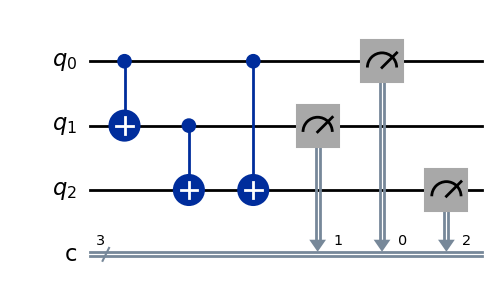

In [14]:
qc = QuantumCircuit(3, 3)
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(0, 2)
qc.measure([0, 1, 2], [0, 1, 2])
qc.draw("mpl")

# Simulated Hardware
## Run the circuit 50 times with the custom transpiler and then with the Qiskit transpiler

In [16]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

#Testing first with a simulator, then with a real backend
backend = FakeFez()

from QiskitTranspiler.transpiler.transpile import transpile

transpiled_circuit = transpile(qc, backend)

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


In [18]:
sampler = Sampler(mode=backend)

experiment_accuracies = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "000":
            acc_sum += count
    accuracy = acc_sum / 1024
    experiment_accuracies.append(accuracy)

print("Average accuracy over 50 runs:", sum(experiment_accuracies) / len(experiment_accuracies))
print("Accuracies for each run:", experiment_accuracies)

Average accuracy over 50 runs: 0.0197265625
Accuracies for each run: [0.021484375, 0.0166015625, 0.017578125, 0.025390625, 0.029296875, 0.0126953125, 0.0234375, 0.0205078125, 0.01171875, 0.0205078125, 0.025390625, 0.015625, 0.0146484375, 0.0166015625, 0.017578125, 0.0224609375, 0.0185546875, 0.01953125, 0.0205078125, 0.0185546875, 0.01953125, 0.0244140625, 0.0234375, 0.01953125, 0.0185546875, 0.01171875, 0.021484375, 0.01953125, 0.015625, 0.015625, 0.021484375, 0.0185546875, 0.0126953125, 0.0244140625, 0.013671875, 0.01953125, 0.0205078125, 0.029296875, 0.0146484375, 0.0224609375, 0.0263671875, 0.0234375, 0.013671875, 0.0185546875, 0.0185546875, 0.0205078125, 0.021484375, 0.01953125, 0.0263671875, 0.0224609375]


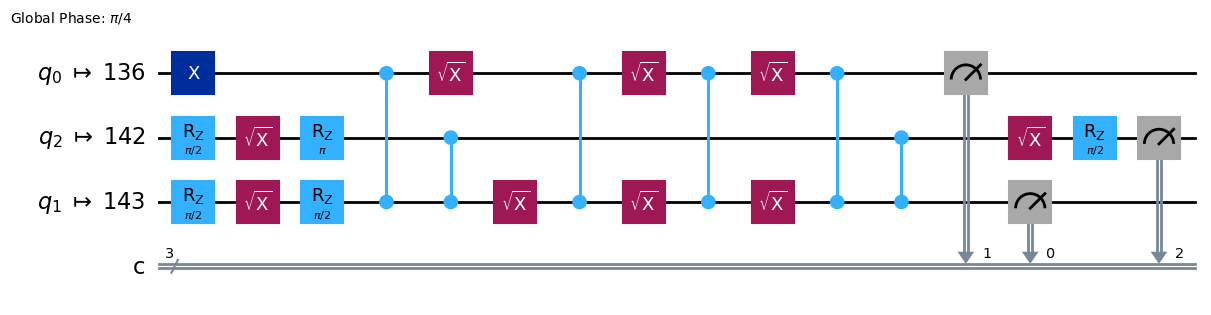

In [7]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit import transpile

#Testing first with a simulator, then with a real backend
backend = FakeFez()

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")

In [ ]:
sampler = Sampler(mode=backend)

experiment_errors = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "000":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)

print("Average error over 50 runs (Qiskit transpiler):", sum(experiment_errors) / len(experiment_errors))
print("Errors for each run:", experiment_errors)

Average error over 50 runs (Qiskit transpiler): 0.036328125
Errors for each run: [0.029296875, 0.0283203125, 0.0419921875, 0.0478515625, 0.0244140625, 0.0439453125, 0.0322265625, 0.0341796875, 0.041015625, 0.03515625, 0.0390625, 0.041015625, 0.0400390625, 0.0419921875, 0.03515625, 0.0361328125, 0.0439453125, 0.0400390625, 0.0302734375, 0.037109375, 0.037109375, 0.0322265625, 0.0302734375, 0.0302734375, 0.0390625, 0.0322265625, 0.041015625, 0.0380859375, 0.0322265625, 0.0390625, 0.0341796875, 0.048828125, 0.0419921875, 0.048828125, 0.0341796875, 0.0302734375, 0.03125, 0.0400390625, 0.037109375, 0.0302734375, 0.0380859375, 0.0341796875, 0.044921875, 0.03515625, 0.0244140625, 0.025390625, 0.0302734375, 0.029296875, 0.044921875, 0.0380859375]


# REAL QUANTUM HARDWARE
## We run each circuit 10 times with the custom transpiler and 10 times with the Qiskit transpiler

In [3]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

# See all available backends
for b in service.backends():
    print(b.name, b.num_qubits, b.status().pending_jobs)

ibm_fez 156 0
ibm_kingston 156 0
ibm_marrakesh 156 2


In [4]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from QiskitTranspiler.transpiler.transpile import transpile

transpiled_circuit = transpile(qc, backend)
# transpiled_circuit.draw("mpl")

Running on: ibm_fez (156 qubits)
[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


In [5]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7ac4b0eecps73d9akdg
Job ID: d7ac4b8eecps73d9ake0
Job ID: d7ac4bhq1efs73d3sqvg
Job ID: d7ac4bik86tc73a1dhmg
Job ID: d7ac4bpq1efs73d3sr0g
Job ID: d7ac4c2k86tc73a1dho0
Job ID: d7ac4cak86tc73a1dhp0
Job ID: d7ac4cgeecps73d9akhg
Job ID: d7ac4cpq1efs73d3sr3g
Job ID: d7ac4d2k86tc73a1dhqg


In [7]:
job_ids = [
    "d7ac4b0eecps73d9akdg",
    "d7ac4b8eecps73d9ake0",
    "d7ac4bhq1efs73d3sqvg",
    "d7ac4bik86tc73a1dhmg",
    "d7ac4bpq1efs73d3sr0g",
    "d7ac4c2k86tc73a1dho0",
    "d7ac4cak86tc73a1dhp0",
    "d7ac4cgeecps73d9akhg",
    "d7ac4cpq1efs73d3sr3g",
    "d7ac4d2k86tc73a1dhqg",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "000":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7ac4b0eecps73d9akdg: error = 0.1123
Job d7ac4b8eecps73d9ake0: error = 0.0957
Job d7ac4bhq1efs73d3sqvg: error = 0.0996
Job d7ac4bik86tc73a1dhmg: error = 0.1152
Job d7ac4bpq1efs73d3sr0g: error = 0.1045
Job d7ac4c2k86tc73a1dho0: error = 0.1084
Job d7ac4cak86tc73a1dhp0: error = 0.0850
Job d7ac4cgeecps73d9akhg: error = 0.0967
Job d7ac4cpq1efs73d3sr3g: error = 0.0850
Job d7ac4d2k86tc73a1dhqg: error = 0.0996

Average error over runs: 0.1001953125


Running on: ibm_fez (156 qubits)


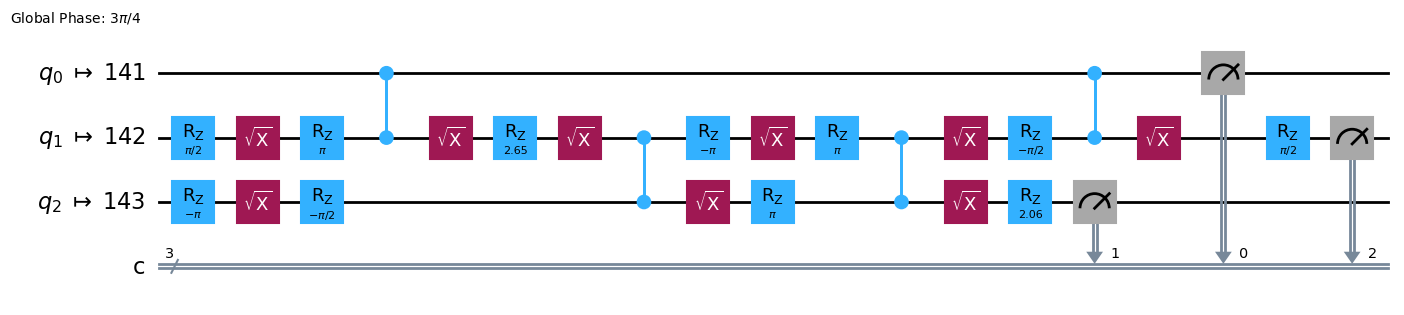

In [10]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from qiskit import transpile

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")
# qc.draw("mpl")

In [11]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7ac6h9q1efs73d3su70
Job ID: d7ac6hhq1efs73d3su8g
Job ID: d7ac6hoeecps73d9anm0
Job ID: d7ac6i3c6das739k0vn0
Job ID: d7ac6iak86tc73a1dl30
Job ID: d7ac6iik86tc73a1dl4g
Job ID: d7ac6iqk86tc73a1dl60
Job ID: d7ac6j0eecps73d9anog
Job ID: d7ac6j8eecps73d9anp0
Job ID: d7ac6jik86tc73a1dl7g


In [13]:
job_ids = [
    "d7ac6h9q1efs73d3su70",
    "d7ac6hhq1efs73d3su8g",
    "d7ac6hoeecps73d9anm0",
    "d7ac6i3c6das739k0vn0",
    "d7ac6iak86tc73a1dl30",
    "d7ac6iik86tc73a1dl4g",
    "d7ac6iqk86tc73a1dl60",
    "d7ac6j0eecps73d9anog",
    "d7ac6j8eecps73d9anp0",
    "d7ac6jik86tc73a1dl7g",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "000":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7ac6h9q1efs73d3su70: error = 0.0264
Job d7ac6hhq1efs73d3su8g: error = 0.0410
Job d7ac6hoeecps73d9anm0: error = 0.0312
Job d7ac6i3c6das739k0vn0: error = 0.0381
Job d7ac6iak86tc73a1dl30: error = 0.0371
Job d7ac6iik86tc73a1dl4g: error = 0.0342
Job d7ac6iqk86tc73a1dl60: error = 0.0273
Job d7ac6j0eecps73d9anog: error = 0.0361
Job d7ac6j8eecps73d9anp0: error = 0.0352
Job d7ac6jik86tc73a1dl7g: error = 0.0342

Average error over runs: 0.03408203125
